In [1]:
import pandas as pd
from scipy.stats import kendalltau,weightedtau
import numpy as np
import matplotlib.pyplot as plt
import dcor

## Fragile Paper

In [2]:
IF_1 = pd.read_csv("TrainSet_Fragile/IF_Train_Set_Fragile_1.csv")
IF_2 = pd.read_csv("TrainSet_Fragile/IF_Train_Set_Fragile_2.csv")
IF_3 = pd.read_csv("TrainSet_Fragile/IF_Train_Set_Fragile_3.csv")
IF_4 = pd.read_csv("TrainSet_Fragile/IF_Train_Set_Fragile_4.csv")
IF_5 = pd.read_csv("TrainSet_Fragile/IF_Train_Set_Fragile_5.csv")

TC_1 = pd.read_csv("TrainSet_Fragile/TC_Train_Set_Fragile_1.csv")
TC_2 = pd.read_csv("TrainSet_Fragile/TC_Train_Set_Fragile_2.csv")
TC_3 = pd.read_csv("TrainSet_Fragile/TC_Train_Set_Fragile_3.csv")
TC_4 = pd.read_csv("TrainSet_Fragile/TC_Train_Set_Fragile_4.csv")
TC_5 = pd.read_csv("TrainSet_Fragile/TC_Train_Set_Fragile_5.csv")

## Ours

In [3]:
IF_1000 = pd.read_csv("TrainSet_Syn_Median/IF_Train_Set_1.csv")
IF_2000 = pd.read_csv("TrainSet_Syn_Median/IF_Train_Set_2.csv")
IF_4000 = pd.read_csv("TrainSet_Syn_Median/IF_Train_Set_3.csv")
IF_8000 = pd.read_csv("TrainSet_Syn_Median/IF_Train_Set_4.csv")
IF_16000 = pd.read_csv("TrainSet_Syn_Median/IF_Train_Set_5.csv")

TC_1000 = pd.read_csv("TrainSet_Syn_Median/TC_Train_Set_1.csv")
TC_2000 = pd.read_csv("TrainSet_Syn_Median/TC_Train_Set_2.csv")
TC_4000 = pd.read_csv("TrainSet_Syn_Median/TC_Train_Set_3.csv")
TC_8000 = pd.read_csv("TrainSet_Syn_Median/TC_Train_Set_4.csv")
TC_16000 = pd.read_csv("TrainSet_Syn_Median/TC_Train_Set_5.csv")

In [4]:
IF_lists_fragile = [IF_1,IF_2,IF_3,IF_4,IF_5]
TC_lists_fragile = [TC_1,TC_2,TC_3,TC_4,TC_5]

In [5]:
IF_lists = [IF_1000,IF_2000,IF_4000,IF_8000,IF_16000]
TC_lists = [TC_1000,TC_2000,TC_4000,TC_8000,TC_16000]

In [6]:
print(IF_lists[0])

     Train_ID     Score
0         350  0.193873
1         784  0.136875
2         715  0.117447
3         127  0.103848
4         227  0.100488
..        ...       ...
995       465 -0.386642
996       794 -0.414346
997       290 -0.447026
998       941 -0.532064
999       609 -0.567104

[1000 rows x 2 columns]


In [7]:
print(IF_lists_fragile[0])

     Train_ID  Highest_Loss_Influence  Median_Loss_Influence
0           1               -0.294776               0.020249
1           2               -9.127144               0.805699
2           3              -22.384144               2.044431
3           4               -0.044071               0.033635
4           5               -1.752221               0.080380
..        ...                     ...                    ...
995       996               -0.029218               0.002344
996       997              -13.494657               0.269306
997       998               -5.418081               0.563714
998       999               -8.885489               0.036880
999      1000                1.299582               0.728404

[1000 rows x 3 columns]


In [8]:
num_runs = len(IF_lists)
kts = []
for i in range(num_runs):
    df1 = IF_lists[i].sort_values(by=["Train_ID"])
    df2 = IF_lists_fragile[i]
    kt, _ = kendalltau(df1["Score"], df2["Highest_Loss_Influence"])
    kts.append(kt)
    print(f"Run_{0}_IF vs Run_{i+1}_IF: Weighted's Tau = {kt:.4f}")


Run_0_IF vs Run_1_IF: Weighted's Tau = -0.1664
Run_0_IF vs Run_2_IF: Weighted's Tau = -0.4085
Run_0_IF vs Run_3_IF: Weighted's Tau = -0.6085
Run_0_IF vs Run_4_IF: Weighted's Tau = -0.7377
Run_0_IF vs Run_5_IF: Weighted's Tau = -0.7426


In [9]:
num_runs = len(IF_lists)
kts = []
for i in range(num_runs):
    df1 = TC_lists[i].sort_values(by=["Train_ID"])
    df2 = TC_lists_fragile[i]
    kt, _ = kendalltau(df1["Score"], df2["Highest_Loss_Influence"])
    kts.append(kt)
    print(f"Run_{0}_TC vs Run_{i+1}_TC: Weighted's Tau = {kt:.4f}")


Run_0_TC vs Run_1_TC: Weighted's Tau = 0.8712
Run_0_TC vs Run_2_TC: Weighted's Tau = 0.9050
Run_0_TC vs Run_3_TC: Weighted's Tau = 0.9354
Run_0_TC vs Run_4_TC: Weighted's Tau = 0.9551
Run_0_TC vs Run_5_TC: Weighted's Tau = 0.9291


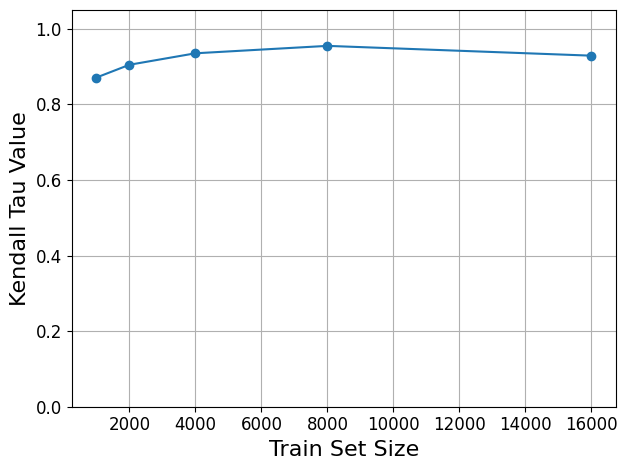

In [10]:
train_sizes = [1000, 2000, 4000, 8000, 16000]
plt.plot(train_sizes, kts, marker='o')

plt.xlabel("Train Set Size", fontsize = 16)
plt.ylabel("Kendall Tau Value", fontsize = 16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0, 1.05)
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "FragileVsoursmedian.png",
    dpi=600,
    bbox_inches="tight"
)


plt.show()